# 03 — Bên trong bộ mã hoá thị giác

Bảng phân rã thời gian của dự án cho thấy **bộ mã hoá thị giác chiếm hơn một nửa thời
gian**, nhiều hơn cả mô hình ngôn ngữ đang xử lý hơn một nghìn token. Notebook này mở bộ
mã hoá ra: ảnh được cắt thành ô thế nào, mỗi ô thành vector ra sao, pixel shuffle nén token
thế nào — và **đếm FLOP** để thấy vì sao phần thị giác đắt đến vậy.

Nền tảng cần có: Transformer và attention (bạn đã vững); notebook 04 (FLOP, tốc độ tính
đỉnh của GPU).

| Mục | Nội dung |
|---|---|
| 1 | Cắt ảnh thành ô |
| 2 | Patch embedding: một ô thành 729 vector |
| 3 | Vision Transformer |
| 4 | Pixel shuffle: 729 vector thành 81 token |
| 5 | Đếm FLOP: vì sao phần thị giác đắt |
| 6 | Kiểm chứng: thời gian tỉ lệ với số ô |

In [1]:
import math, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.harness import load_samples, PROMPT
from transformers import AutoProcessor, AutoModelForImageTextToText

plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})
dev = "cuda"
MODEL = "HuggingFaceTB/SmolVLM-Instruct"

def processor(edge=1536, split=True):
    """Same processor settings as bench/harness.py uses for each configuration."""
    kw = {"do_image_splitting": split}
    if split:
        kw["size"] = {"longest_edge": edge}
    return AutoProcessor.from_pretrained(MODEL, **kw)

sample = load_samples(1, seed=0)[0]
img = sample["image"].convert("RGB")
print("image size (w x h):", img.size, "| question:", sample["query"])

image size (w x h): (800, 557) | question: By what year is it expected that consumer sales of cannabidiol will reach around 1.8 billion U.S. dollars?


## 1. Cắt ảnh thành ô

Bộ mã hoá thị giác (SigLIP) được huấn luyện trên ảnh vuông **384×384**. Để xem một ảnh lớn
mà không làm mất chi tiết, bộ tiền xử lý của SmolVLM:

1. Phóng ảnh sao cho **cạnh dài** bằng `longest_edge` (mặc định 1536 = 4 × 384), giữ tỉ lệ.
2. Làm tròn **lên** mỗi cạnh tới bội số của 384.
3. Cắt thành các ô 384×384.
4. Thêm **một ô toàn cảnh**: cả ảnh thu nhỏ về 384×384, để mô hình vẫn thấy bố cục chung.

$$\text{số ô} = \Big\lceil \tfrac{W'}{384} \Big\rceil \times \Big\lceil \tfrac{H'}{384} \Big\rceil + 1$$

với $W', H'$ là kích thước sau bước 1.

**Ký hiệu mới**
- $W', H'$: chiều rộng và chiều cao sau khi phóng · $\lceil\cdot\rceil$: làm tròn lên

In [2]:
def tiles_formula(w, h, edge):
    s = edge / max(w, h)
    return math.ceil(w * s / 384) * math.ceil(h * s / 384) + 1

for edge, split in [(1536, True), (768, True), (None, False)]:
    p = processor(edge or 1536, split)
    pv = p.image_processor(img, return_tensors="pt")["pixel_values"]
    formula = tiles_formula(*img.size, edge) if split else 1
    label = f"longest edge {edge}" if split else "no splitting"
    print(f"{label:<18} processor: {pv.shape[1]:>2} tiles | formula: {formula:>2} tiles")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


longest edge 1536  processor: 13 tiles | formula: 13 tiles


longest edge 768   processor:  5 tiles | formula:  5 tiles


no splitting       processor:  1 tiles | formula:  1 tiles


Công thức khớp với bộ tiền xử lý. Ảnh 800×557 được phóng thành 1536×1070, làm tròn lên
1536×1152, tức lưới 4×3 = 12 ô, cộng ô toàn cảnh là **13 ô**. Giảm cạnh dài xuống 768 cho
lưới 2×2 cộng 1 = **5 ô**. Đây chính là hai "đòn bẩy giảm số ô" của dự án.

Nhìn các ô mà mô hình thực sự nhận được:

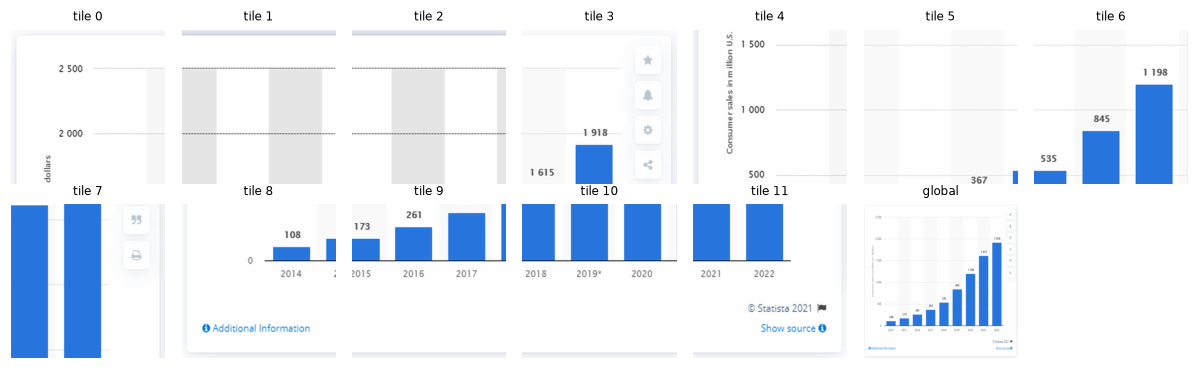

In [3]:
pv = processor().image_processor(img, return_tensors="pt")["pixel_values"][0]    # 13 x 3 x 384 x 384
fig, axes = plt.subplots(2, 7, figsize=(11, 3.4))
for i, ax in enumerate(axes.flat):
    ax.axis("off")
    if i < pv.shape[0]:
        t = pv[i].permute(1, 2, 0).numpy()
        ax.imshow((t - t.min()) / (t.max() - t.min() + 1e-6))
        ax.set_title("global" if i == pv.shape[0] - 1 else f"tile {i}", fontsize=8)
plt.tight_layout(); plt.show()

## 2. Patch embedding: một ô thành 729 vector

Vision Transformer (ViT) xem một ảnh như một **chuỗi mảnh** (patch). SigLIP cắt ô 384×384
thành các mảnh **14×14 pixel**: $\lfloor 384/14 \rfloor = 27$ mảnh mỗi chiều, tức
$27^2 = 729$ mảnh (6 pixel cuối mỗi chiều bị bỏ). Mỗi mảnh có $14 \times 14 \times 3 = 588$
giá trị, được **chiếu tuyến tính** thành một vector 1152 chiều — đúng vai trò của embedding
token trong mô hình ngôn ngữ.

Trong code, phép chiếu này viết thành một **tích chập** kích thước 14, bước nhảy 14: vì các
cửa sổ không chồng lên nhau, tích chập đó chính là "cắt mảnh, trải phẳng, nhân ma trận".
Kiểm chứng hai cách cho cùng kết quả:

**Ký hiệu mới**
- $\lfloor\cdot\rfloor$: làm tròn xuống · patch: mảnh ảnh 14×14 pixel

In [4]:
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()
vis = model.model.vision_model
conv = vis.embeddings.patch_embedding
print(conv)

tile = pv[:1].to(dev, torch.bfloat16)                                   # 1 x 3 x 384 x 384
with torch.no_grad():
    by_conv = conv(tile).flatten(2).transpose(1, 2)                     # 1 x 729 x 1152
    patches = tile[:, :, :378, :378].unfold(2, 14, 14).unfold(3, 14, 14)     # 1 x 3 x 27 x 27 x 14 x 14
    patches = patches.permute(0, 2, 3, 1, 4, 5).reshape(1, 729, 588)          # cut, then flatten
    by_matmul = patches.float() @ conv.weight.reshape(1152, 588).float().T + conv.bias.float()
print("patch sequence:", tuple(by_conv.shape))
print(f"conv vs cut-and-matmul: max difference {(by_conv.float() - by_matmul).abs().max():.3f} "
      f"(values up to {by_conv.float().abs().max():.1f}; bf16 rounding)")

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
patch sequence: (1, 729, 1152)
conv vs cut-and-matmul: max difference 0.015 (values up to 5.1; bf16 rounding)


Sau phép chiếu, cộng thêm **embedding vị trí** (một vector học được cho mỗi vị trí trong lưới
27×27), vì attention tự nó không biết mảnh nào nằm ở đâu.

## 3. Vision Transformer

729 vector đó đi qua **27 lớp encoder** Transformer. Khác mô hình ngôn ngữ ở một điểm:
attention **hai chiều** — không có mặt nạ nhân quả, mọi mảnh nhìn thấy mọi mảnh trong cùng
ô. Các ô được mã hoá **độc lập** với nhau: 13 ô là 13 chuỗi 729 phần tử, xếp thành một lô.

In [5]:
vc = model.config.vision_config
tc = model.config.text_config
n_vis = sum(p.numel() for p in vis.parameters())
n_conn = sum(p.numel() for p in model.model.connector.parameters())
n_lm = sum(p.numel() for p in model.model.text_model.parameters())
n_emb = model.model.text_model.embed_tokens.weight.numel()
print(f"vision : {vc.num_hidden_layers} layers, d = {vc.hidden_size}, heads = {vc.num_attention_heads}, "
      f"MLP {vc.intermediate_size} -> {n_vis / 1e6:.0f} M params")
print(f"text   : {tc.num_hidden_layers} layers, d = {tc.hidden_size}, heads = {tc.num_attention_heads}, "
      f"MLP {tc.intermediate_size} -> {n_lm / 1e6:.0f} M params ({n_emb / 1e6:.0f} M of them token embeddings)")
print(f"connector: {n_conn / 1e6:.1f} M params")

vision : 27 layers, d = 1152, heads = 16, MLP 4304 -> 413 M params
text   : 24 layers, d = 2048, heads = 32, MLP 8192 -> 1711 M params (101 M of them token embeddings)
connector: 21.2 M params


Bộ mã hoá thị giác chỉ có khoảng 413 triệu tham số — **một phần tư** mô hình ngôn ngữ. Vậy vì
sao nó lại tốn nhiều thời gian hơn? Câu trả lời nằm ở **số token** nó phải xử lý (mục 5).

## 4. Pixel shuffle: 729 vector thành 81 token

Nếu đưa thẳng 729 vector mỗi ô vào mô hình ngôn ngữ, 13 ô sẽ thành gần 9.500 token. Connector
của SmolVLM nén trước bằng **pixel shuffle**: gộp mỗi khối **3×3 mảnh liền kề** thành **một**
token, bằng cách **nối** 9 vector 1152 chiều thành một vector $9 \times 1152 = 10\,368$ chiều.
Lưới 27×27 thành lưới 9×9 = **81 token**. Sau đó một lớp tuyến tính chiếu 10.368 chiều về 2048
— số chiều của mô hình ngôn ngữ.

$$\underbrace{27 \times 27}_{729} \times 1152
\;\xrightarrow{\text{gộp khối } 3\times 3}\;
\underbrace{9 \times 9}_{81} \times 10\,368
\;\xrightarrow{\;W_{\text{proj}}\;}\;
81 \times 2048$$

Không thông tin nào bị bỏ ở bước gộp — nó chỉ **dời** thông tin từ chiều chuỗi sang chiều đặc
trưng. Để thấy rõ mảnh nào đi vào token nào, chạy hàm `pixel_shuffle` của transformers trên một
đầu vào giả, trong đó mỗi vector chỉ ghi **toạ độ (hàng, cột)** của mảnh:

**Ký hiệu mới**
- $W_{\text{proj}}$: ma trận chiếu của connector ($10\,368 \times 2048$ — khớp 21,2 triệu tham số ở trên)

In [6]:
shuffle = model.model.connector.pixel_shuffle
coords = torch.tensor([[r, c] for r in range(27) for c in range(27)], dtype=torch.float)[None]   # 1 x 729 x 2
out = shuffle(coords, 3)[0].reshape(81, 9, 2).int()                                              # 81 tokens x 9 patches
for t in [0, 1, 9, 80]:
    print(f"token {t:>2} <- patches (row, col):", [tuple(v.tolist()) for v in out[t]])

token  0 <- patches (row, col): [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
token  1 <- patches (row, col): [(0, 3), (0, 4), (0, 5), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5)]
token  9 <- patches (row, col): [(3, 0), (3, 1), (3, 2), (4, 0), (4, 1), (4, 2), (5, 0), (5, 1), (5, 2)]
token 80 <- patches (row, col): [(24, 24), (24, 25), (24, 26), (25, 24), (25, 25), (25, 26), (26, 24), (26, 25), (26, 26)]


Token 0 chứa khối 3×3 ở góc trên trái, token 1 là khối kế bên phải, token 9 bắt đầu hàng khối
thứ hai — đúng như mô tả, theo thứ tự hàng trước cột sau. Giờ kiểm trên đầu ra **thật** của bộ
mã hoá: nội dung mỗi token phải trùng khớp với 9 vector của khối tương ứng, theo đúng thứ tự đó.

In [7]:
with torch.no_grad():
    h = vis(pixel_values=tile).last_hidden_state                        # 1 x 729 x 1152
    shuffled = shuffle(h, model.config.scale_factor)                     # 1 x 81 x 10368
print("encoder output:", tuple(h.shape), "-> after pixel shuffle:", tuple(shuffled.shape))

grid = h[0].reshape(27, 27, 1152)
ok = sum(torch.equal(shuffled[0, i * 9 + j].reshape(9, 1152),
                     grid[3 * i:3 * i + 3, 3 * j:3 * j + 3].reshape(9, 1152))
         for i in range(9) for j in range(9))
print(f"{ok}/81 output tokens are exactly the 9 patch vectors of their 3x3 block")

encoder output: (1, 729, 1152) -> after pixel shuffle: (1, 81, 10368)
81/81 output tokens are exactly the 9 patch vectors of their 3x3 block


Cả 81 token đều đúng như mô tả. Lợi ích: mô hình ngôn ngữ chỉ phải xử lý 81 thay vì 729 token
mỗi ô, trong khi phép chiếu 10.368 → 2048 rất rẻ (bảng phân rã: connector chỉ 2,6 ms).

## 5. Đếm FLOP: vì sao phần thị giác đắt

Notebook 04 dùng cách đếm cho một lớp tuyến tính: nhân $T$ token với ma trận $d_{in} \times
d_{out}$ tốn $2\,T\,d_{in}\,d_{out}$ FLOP — mỗi trọng số tham gia một phép nhân và một phép cộng
cho mỗi token. Cộng trên mọi lớp tuyến tính của mô hình:

$$\text{FLOP}_{\text{tuyến tính}} \approx 2 \times N \times T$$

với $N$ là số tham số của các lớp tuyến tính và $T$ là số token. Attention còn thêm phần tính
điểm $QK^\top$ và nhân với $V$: mỗi phần $2 \times n \times d$ FLOP cho mỗi token ở mỗi lớp, với
$n$ là độ dài chuỗi mà token đó nhìn thấy:

$$\text{FLOP}_{\text{attention}} \approx 4 \times n \times d \times L \times T$$

**Ký hiệu mới**
- $N$: số tham số (không tính embedding tra bảng, vì tra bảng không tốn FLOP)
- $T$: tổng số token đi qua mô hình · $n$: độ dài chuỗi attention · $d$: số chiều · $L$: số lớp

**Liên hệ:** công thức "$2N$ FLOP mỗi token cho lượt xuôi" cũng là gốc của quy tắc
"huấn luyện tốn khoảng $6ND$ FLOP" trong các bài về scaling law (lượt ngược tốn gấp đôi lượt
xuôi, $D$ là số token huấn luyện).

Áp vào một câu hỏi ChartQA:
- **Thị giác**: 13 ô × 729 mảnh = 9.477 token; attention trong từng ô, $n = 729$.
- **Prefill ngôn ngữ**: 1.251 token; attention nhân quả nên trung bình mỗi token nhìn $n \approx 1251/2$.

In [8]:
n_tok_vis = 13 * 729
n_tok_lm = 1251
vis_lin = 2 * n_vis * n_tok_vis
vis_att = 4 * 729 * vc.hidden_size * vc.num_hidden_layers * n_tok_vis
lm_lin = 2 * (n_lm - n_emb) * n_tok_lm
lm_att = 4 * (n_tok_lm / 2) * tc.hidden_size * tc.num_hidden_layers * n_tok_lm
vis_total, lm_total = vis_lin + vis_att, lm_lin + lm_att
print(f"vision   : {vis_lin / 1e12:.2f} TFLOP linear + {vis_att / 1e12:.2f} attention = {vis_total / 1e12:.2f} TFLOP")
print(f"LM prefill: {lm_lin / 1e12:.2f} TFLOP linear + {lm_att / 1e12:.2f} attention = {lm_total / 1e12:.2f} TFLOP")
print(f"FLOP ratio vision / prefill = {vis_total / lm_total:.2f}")

import json
bd = json.loads(open("../results/breakdown.json").read())["median_ms"]
print(f"time ratio (breakdown.json) = {bd['vision'] / bd['llm_prefill']:.2f}   "
      f"({bd['vision']:.0f} ms vs {bd['llm_prefill']:.0f} ms)")
print(f"achieved: vision {vis_total / (bd['vision'] / 1e3) / 1e12:.0f} TFLOP/s, "
      f"prefill {lm_total / (bd['llm_prefill'] / 1e3) / 1e12:.0f} TFLOP/s")

vision   : 7.83 TFLOP linear + 0.86 attention = 8.69 TFLOP
LM prefill: 4.03 TFLOP linear + 0.15 attention = 4.18 TFLOP
FLOP ratio vision / prefill = 2.08
time ratio (breakdown.json) = 1.97   (472 ms vs 239 ms)
achieved: vision 18 TFLOP/s, prefill 18 TFLOP/s


Chỉ bằng phép đếm, ta dự đoán bộ mã hoá thị giác tốn khoảng **gấp đôi** FLOP của prefill ngôn
ngữ — và tỉ lệ thời gian đo được gần như đúng bằng tỉ lệ đó (hai dòng giữa của ô trên). Bí ẩn "413 triệu
tham số mà chậm hơn 1,7 tỉ" được giải: bộ mã hoá có ít tham số hơn **4 lần**, nhưng xử lý nhiều
token hơn **7,6 lần** (9.477 so với 1.251). Pixel shuffle nén token **sau** bộ mã hoá, nên bộ mã
hoá vẫn phải trả giá cho toàn bộ 9.477 mảnh.

Hai con số phụ đáng chú ý:
- **Attention chỉ chiếm khoảng 10%** FLOP ở cả hai phần. Chi phí gần như **tỉ lệ thuận** với số
  token — căn cứ cho giả định của định luật Amdahl ở notebook 02.
- Tốc độ đạt được khoảng 15–20 TFLOP/s, dưới một nửa đỉnh 43 TFLOP/s đo ở notebook 04. Tỉ lệ
  này gọi là **mức sử dụng FLOP của mô hình** (model FLOPs utilization, MFU); phần hụt là các
  phép tính không phải nhân ma trận (chuẩn hoá, kích hoạt, softmax) và các ma trận không đủ lớn
  để lấp đầy GPU.

**Ký hiệu mới**
- MFU: FLOP/s đạt được chia cho FLOP/s đỉnh của phần cứng

## 6. Kiểm chứng: thời gian tỉ lệ với số ô

Vì các ô được mã hoá độc lập và attention chỉ chiếm phần nhỏ, thời gian của bộ mã hoá phải
tăng **tuyến tính** theo số ô — bậc $O(\text{số ô})$ theo ký hiệu của notebook 04. Đo với 1 đến
13 ô:

 1 tiles:   45.2 ms  ( 45.2 ms per tile)
 2 tiles:   98.8 ms  ( 49.4 ms per tile)
 3 tiles:  146.0 ms  ( 48.7 ms per tile)
 5 tiles:  219.7 ms  ( 43.9 ms per tile)
 7 tiles:  259.1 ms  ( 37.0 ms per tile)
 9 tiles:  319.8 ms  ( 35.5 ms per tile)
11 tiles:  378.1 ms  ( 34.4 ms per tile)
13 tiles:  435.3 ms  ( 33.5 ms per tile)
linear fit: 31.1 ms per tile + 39.4 ms


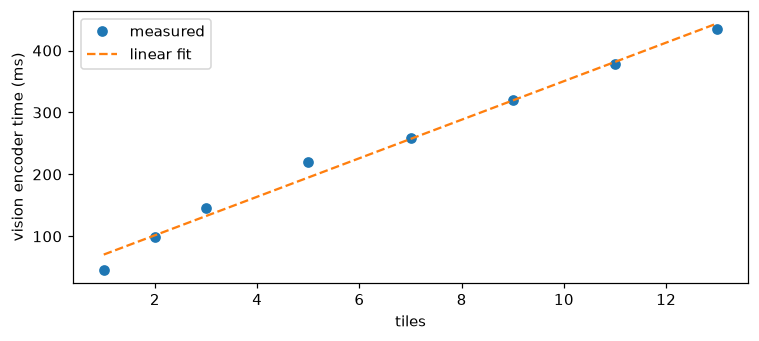

In [9]:
def timed(fn, reps=7):
    for _ in range(2): fn()
    ts = []
    for _ in range(reps):
        s, e = torch.cuda.Event(True), torch.cuda.Event(True)
        torch.cuda.synchronize(); s.record(); fn(); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    return float(np.median(ts))

all_tiles = pv.to(dev, torch.bfloat16)
ks = [1, 2, 3, 5, 7, 9, 11, 13]
with torch.no_grad():
    ts = [timed(lambda: vis(pixel_values=all_tiles[:k])) for k in ks]
slope, intercept = np.polyfit(ks, ts, 1)
for k, t in zip(ks, ts):
    print(f"{k:>2} tiles: {t:6.1f} ms  ({t / k:5.1f} ms per tile)")
print(f"linear fit: {slope:.1f} ms per tile + {intercept:.1f} ms")
plt.plot(ks, ts, "o", label="measured"); plt.plot(ks, np.polyval([slope, intercept], ks), "--", label="linear fit")
plt.xlabel("tiles"); plt.ylabel("vision encoder time (ms)"); plt.legend(); plt.tight_layout(); plt.show()

Thời gian tăng gần như tuyến tính theo số ô, với độ dốc khoảng 30–35 ms mỗi ô. Mỗi ô không tốn
**hoàn toàn** như nhau: với 1–5 ô, mỗi ô tốn khoảng 45 ms; với 9–13 ô, khoảng 35 ms. Lý do
là các ma trận của một lô nhỏ chưa đủ lớn để lấp đầy GPU (cường độ số học thấp hơn, notebook 04),
nên lô lớn dùng phần cứng hiệu quả hơn. Dù vậy, giảm từ 13 xuống 5 ô vẫn cắt gần một nửa thời
gian của bộ mã hoá — đòn bẩy mạnh nhất của dự án.

(Một lần đo trên GPU laptop dao động vài phần trăm; notebook 02 bàn về điều này.)

In [10]:
del model; torch.cuda.empty_cache()

## Tóm tắt

| Bước | Biến đổi | Với ảnh 800×557, cạnh dài 1536 |
|---|---|---|
| Cắt ô | ảnh → lưới ô 384×384 + 1 ô toàn cảnh | 13 ô |
| Patch embedding | mỗi ô → 27×27 mảnh 14×14 → vector 1152 chiều | 13 × 729 = 9.477 vector |
| Vision Transformer | 27 lớp, attention hai chiều trong từng ô | 9.477 vector (FLOP ~2× prefill) |
| Pixel shuffle | gộp khối 3×3 → nối thành 10.368 chiều | 13 × 81 = 1.053 token |
| Chiếu | 10.368 → 2048 chiều | 1.053 token vào mô hình ngôn ngữ |

Bài học cho tối ưu: **token ảnh mà mô hình ngôn ngữ nhìn thấy (1.053) không phản ánh chi phí
thật (9.477 mảnh qua bộ mã hoá).** Đòn bẩy nào chỉ giảm số token *sau* connector thì không chạm
được vào phần đắt nhất.